TIME SERIES ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv('Walmart.csv')

# View
print(df.head())
print(df.shape)

# Convert Date
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Sort by time
df = df.sort_values("Date")

# Missing values
print(df.isnull().sum())

# Fill if any
df.fillna(method="ffill", inplace=True)

print(df.info())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
(6435, 8)
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  ----

EDA

             Store                           Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                           6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00.000000256  1.046965e+06      0.069930   
min       1.000000            2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000            2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000            2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000            2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000            2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                            NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.578394      7.999151  
min      -2.060000     2.472000   126.064000      3.879000  
25%      47.460000     2.9

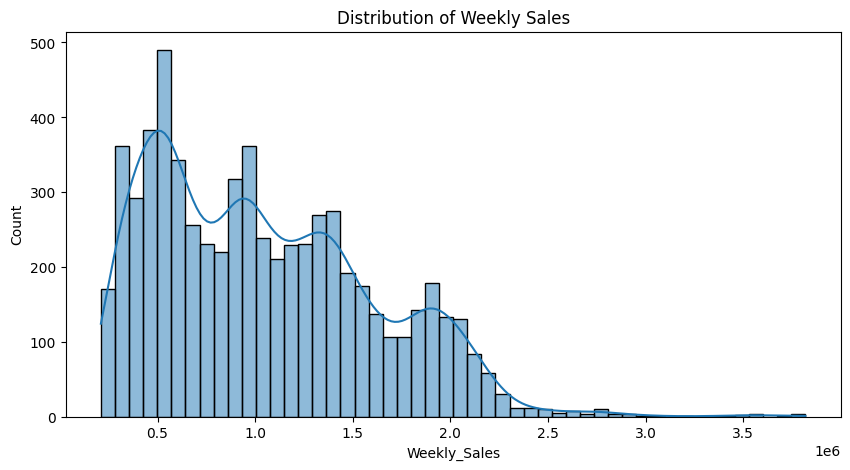

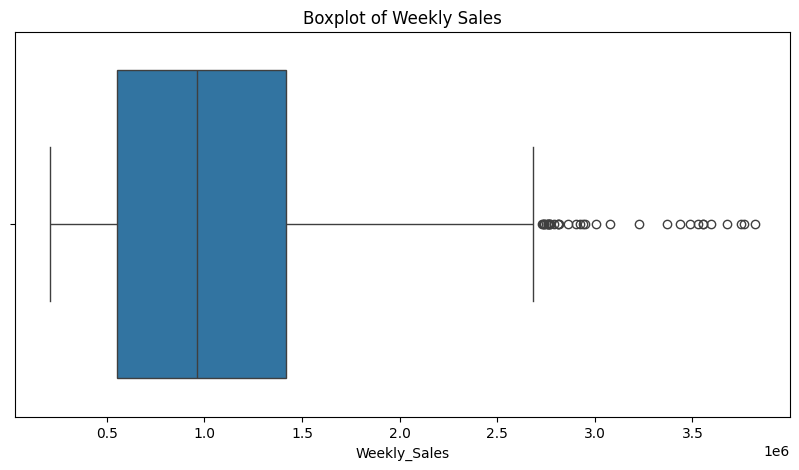

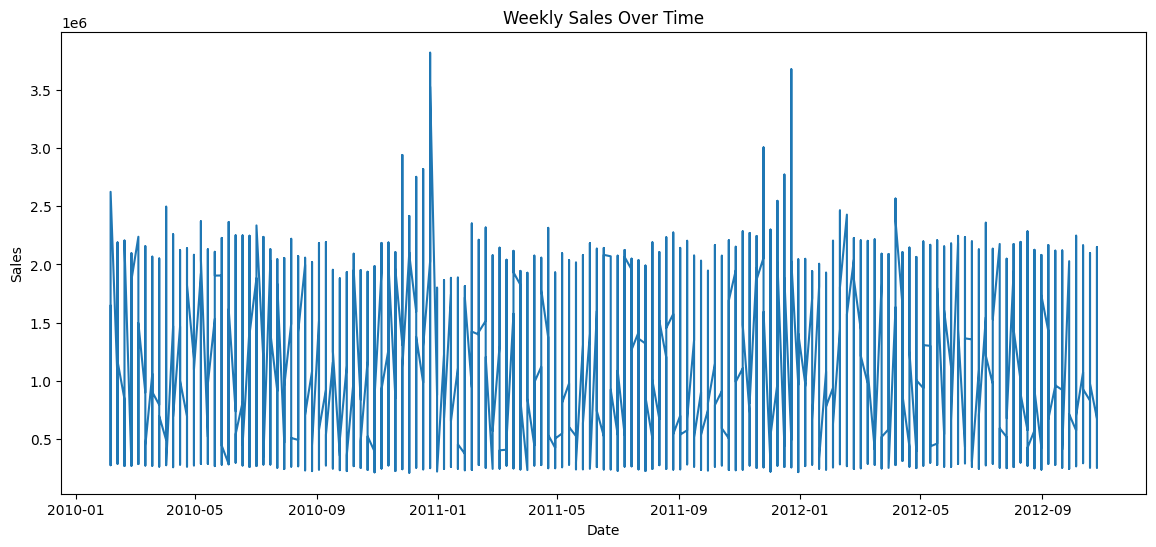

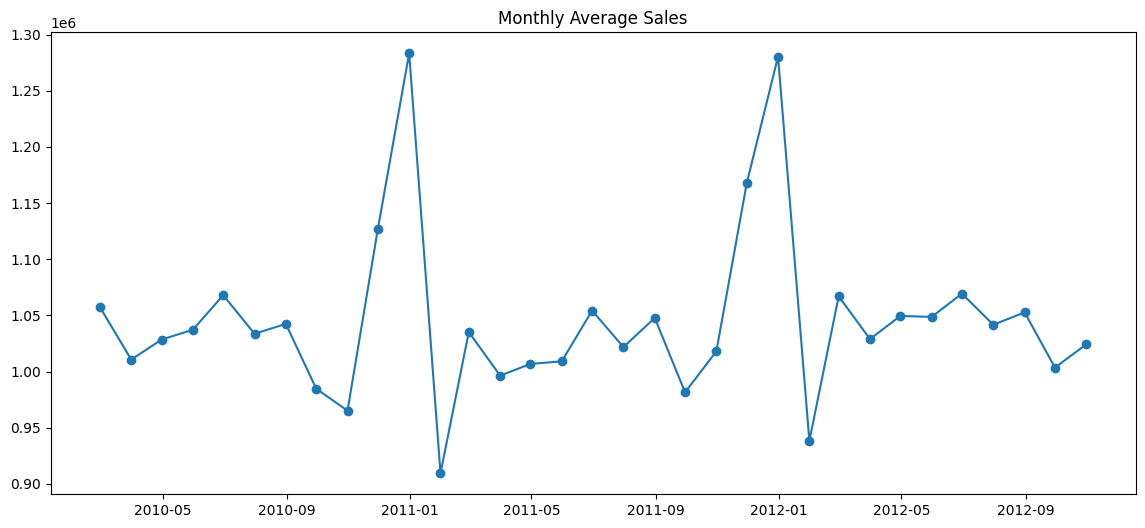

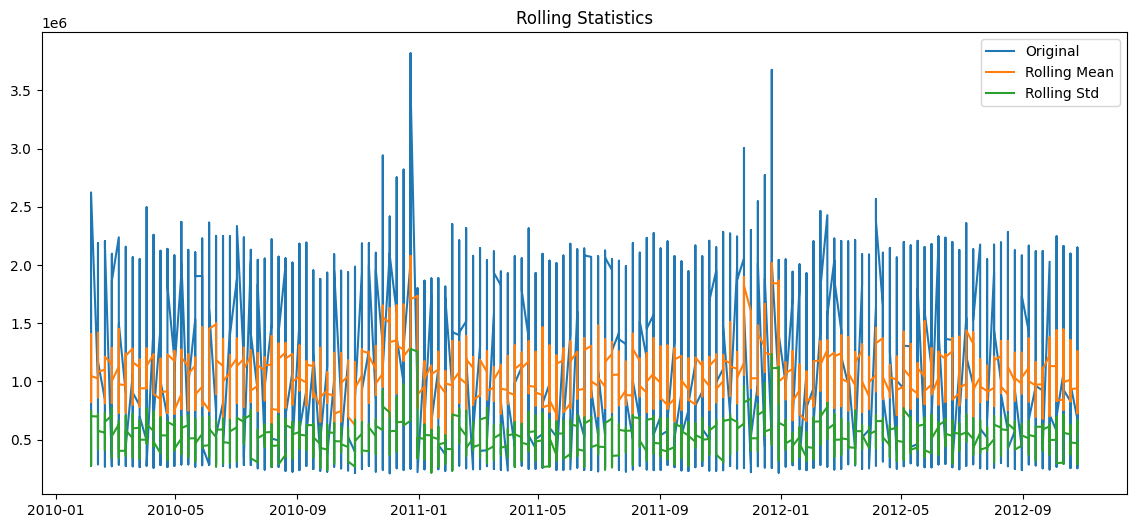

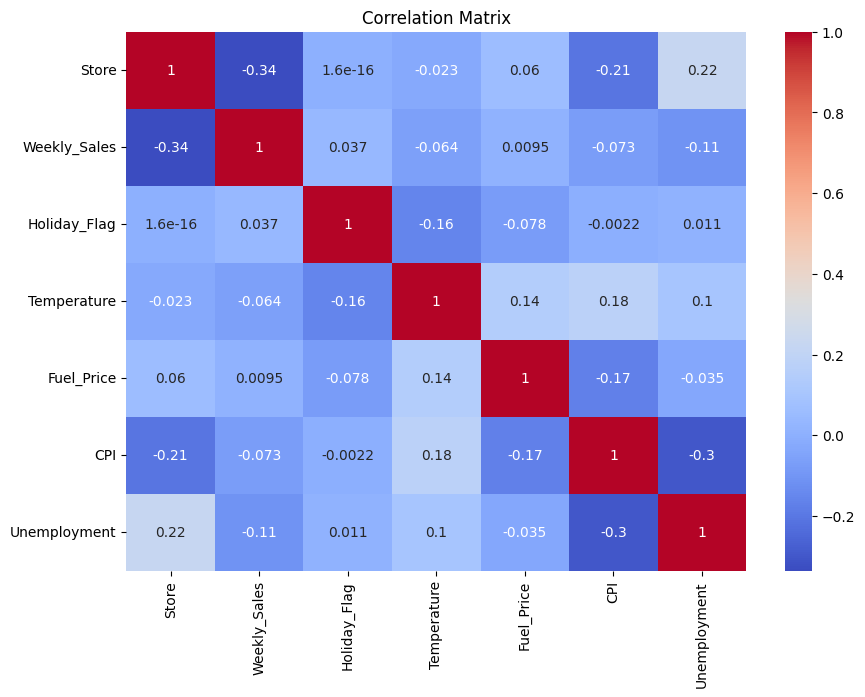

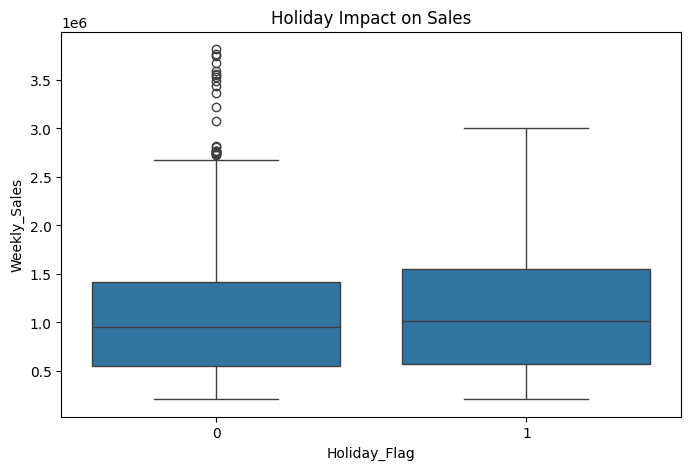

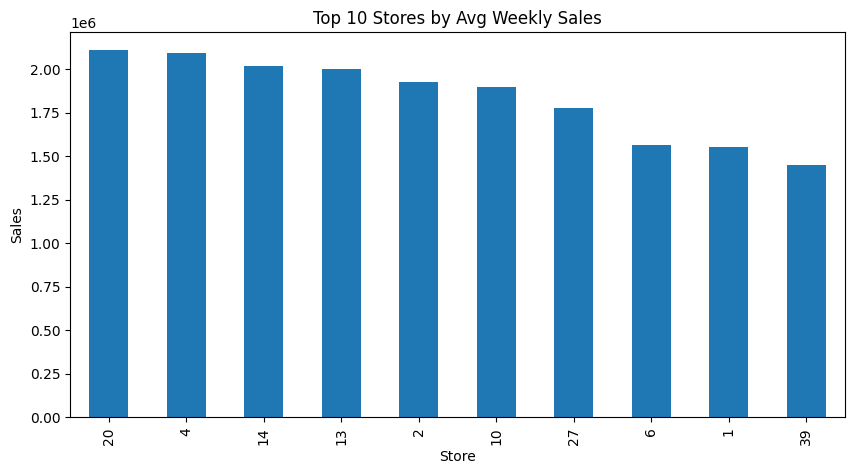

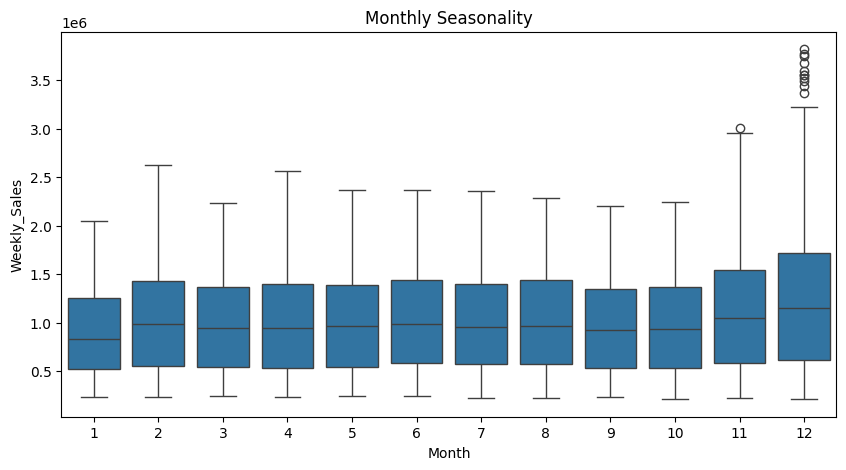

In [4]:
# -----------------------------
# Basic Statistics
# -----------------------------
print(df.describe(include="all"))

# -----------------------------
# Weekly Sales Distribution
# -----------------------------
plt.figure(figsize=(10,5))
sns.histplot(df["Weekly_Sales"], bins=50, kde=True)
plt.title("Distribution of Weekly Sales")
plt.show()

# -----------------------------
# Boxplot for Outliers
# -----------------------------
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Boxplot of Weekly Sales")
plt.show()

# -----------------------------
# Sales Trend Over Time
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Weekly_Sales"])
plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# -----------------------------
# Monthly Average Sales Trend
# -----------------------------
monthly_sales = df.resample("M", on="Date")["Weekly_Sales"].mean()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Average Sales")
plt.show()

# -----------------------------
# Rolling Mean + Rolling Std
# -----------------------------
rolling_mean = df["Weekly_Sales"].rolling(window=12).mean()
rolling_std = df["Weekly_Sales"].rolling(window=12).std()

plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Weekly_Sales"], label="Original")
plt.plot(df["Date"], rolling_mean, label="Rolling Mean")
plt.plot(df["Date"], rolling_std, label="Rolling Std")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# Holiday vs Non-Holiday Sales
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df)
plt.title("Holiday Impact on Sales")
plt.show()

# -----------------------------
# Top 10 Stores by Avg Sales
# -----------------------------
top_store = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_store.plot(kind="bar")
plt.title("Top 10 Stores by Avg Weekly Sales")
plt.ylabel("Sales")
plt.show()

# -----------------------------
# Seasonality by Month
# -----------------------------
df["Month"] = df["Date"].dt.month

plt.figure(figsize=(10,5))
sns.boxplot(x="Month", y="Weekly_Sales", data=df)
plt.title("Monthly Seasonality")
plt.show()

Feature Engineering

In [5]:
# Date based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

# Cyclical encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"]/12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"]/12)

# Lag Features
df["lag_1"] = df["Weekly_Sales"].shift(1)
df["lag_2"] = df["Weekly_Sales"].shift(2)
df["lag_4"] = df["Weekly_Sales"].shift(4)
df["lag_12"] = df["Weekly_Sales"].shift(12)

# Rolling Features
df["roll_mean_4"] = df["Weekly_Sales"].rolling(4).mean()
df["roll_std_4"] = df["Weekly_Sales"].rolling(4).std()

df["roll_mean_12"] = df["Weekly_Sales"].rolling(12).mean()
df["roll_std_12"] = df["Weekly_Sales"].rolling(12).std()

# Expanding Mean
df["expanding_mean"] = df["Weekly_Sales"].expanding().mean()

# Percentage Change
df["pct_change"] = df["Weekly_Sales"].pct_change()

# Drop NaNs from shifting
df.dropna(inplace=True)

print(df.head())
print(df.shape)

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
5434     39 2010-02-05    1230596.80             0        44.30       2.572   
1001      8 2010-02-05    1004137.09             0        34.14       2.572   
4433     32 2010-02-05    1087616.19             0        34.43       2.580   
2002     15 2010-02-05     652122.44             0        19.83       2.954   
4719     34 2010-02-05     956228.96             0        35.44       2.598   

             CPI  Unemployment  Month  Year  ...       lag_1       lag_2  \
5434  209.852966         8.554      2  2010  ...  1034119.21   798593.88   
1001  214.471451         6.299      2  2010  ...  1230596.80  1034119.21   
4433  189.381697         9.014      2  2010  ...  1004137.09  1230596.80   
2002  131.527903         8.350      2  2010  ...  1087616.19  1004137.09   
4719  126.442065         9.521      2  2010  ...   652122.44  1087616.19   

           lag_4      lag_12   roll_mean_4     roll_std_4  roll_mean

Feature Selection + Feature Extraction

In [6]:
# Input / Target
X = df.drop(columns=["Date", "Weekly_Sales"])
y = df["Weekly_Sales"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Select Best Features
selector = SelectKBest(score_func=mutual_info_regression, k=10)
X_selected = selector.fit_transform(X_scaled, y)

selected_cols = X.columns[selector.get_support()]
print("Selected Features:")
print(selected_cols)

# PCA for Feature Extraction
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_selected)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Selected Features:
Index(['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'roll_mean_4', 'roll_std_4', 'roll_mean_12', 'roll_std_12',
       'pct_change'],
      dtype='object')
Explained Variance Ratio:
[0.25582466 0.15217097 0.11305221 0.11141252 0.09823475]


Train/Test Split + Cross Validation + Hyperparameter Tuning

In [7]:
# Time Based Split
split = int(len(X_pca) * 0.8)

X_train = X_pca[:split]
X_test = X_pca[split:]

y_train = y[:split]
y_test = y[split:]

# TimeSeries CV
tscv = TimeSeriesSplit(n_splits=5)

# Model
rf = RandomForestRegressor(random_state=42)

# Parameters
params = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Final Model Training + Prediction

In [8]:
best_model = grid.best_estimator_

# Train final model
best_model.fit(X_train, y_train)

# Predictions
pred = best_model.predict(X_test)

print(pred[:10])

[1612358.59069874  901596.4507868  1810175.90790652  568625.43280436
 1529516.86733862  785430.6758401  1686130.28067941  824358.36136253
  714492.83104256 1016282.07210223]


Plot Actual vs Predicted

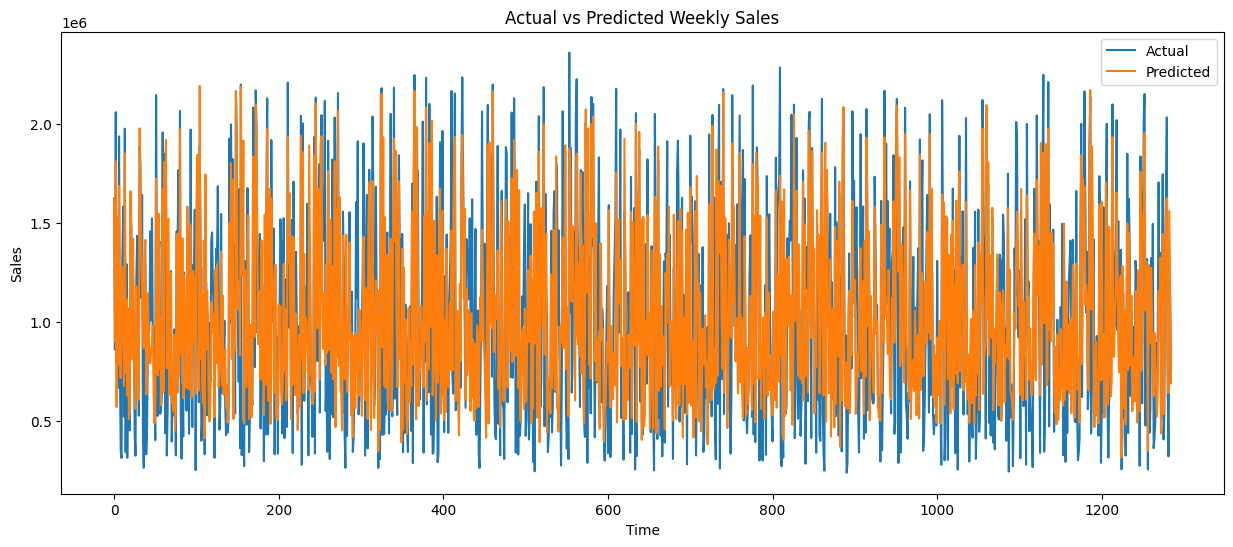

In [9]:
plt.figure(figsize=(15,6))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

Forecast Future 12 Weeks

In [10]:
future_forecast = []

last_input = X_test[-1].reshape(1,-1)

for i in range(12):
    next_pred = best_model.predict(last_input)[0]
    future_forecast.append(next_pred)

print("Next 12 Week Forecast:")
print(future_forecast)

Next 12 Week Forecast:
[np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364), np.float64(688861.9491197364)]


Forecast Plot

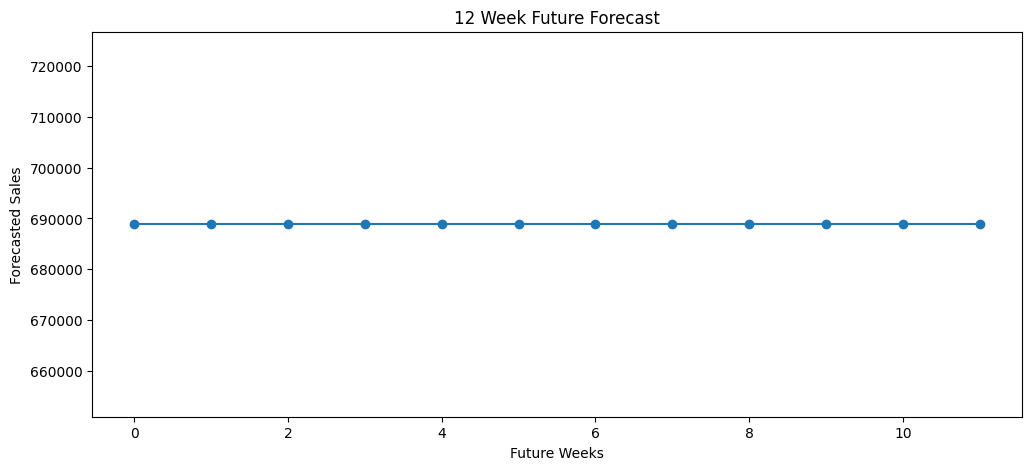

In [11]:
plt.figure(figsize=(12,5))
plt.plot(range(len(future_forecast)), future_forecast, marker='o')
plt.title("12 Week Future Forecast")
plt.xlabel("Future Weeks")
plt.ylabel("Forecasted Sales")
plt.show()

Model Evaluation

In [12]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 282335.5903736468
RMSE: 372423.2451776423
R2 Score: 0.5123059807884782
